In [1]:
import pandas as pd
df = pd.read_csv("carprices-mileage-age-sp.csv")
print(df.head())

   Mileage  Age(yrs)  Sell Price($)
0    69000         6          18000
1    35000         3          34000
2    57000         5          26100
3    22500         2          40000
4    46000         4          31500


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline


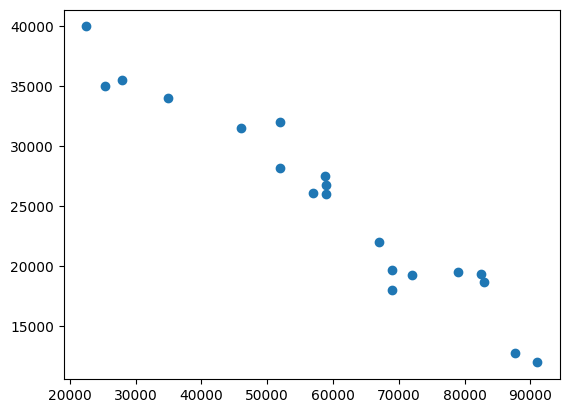

In [3]:
plt.scatter(df["Mileage"], df["Sell Price($)"])

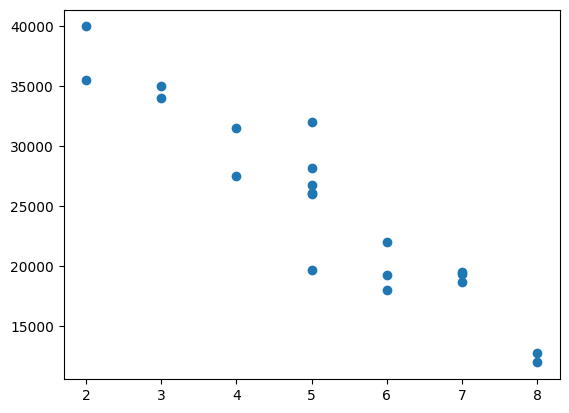

In [4]:
plt.scatter(df["Age(yrs)"], df["Sell Price($)"])

In [5]:
X= df[["Mileage", "Age(yrs)"]]
y= df["Sell Price($)"]

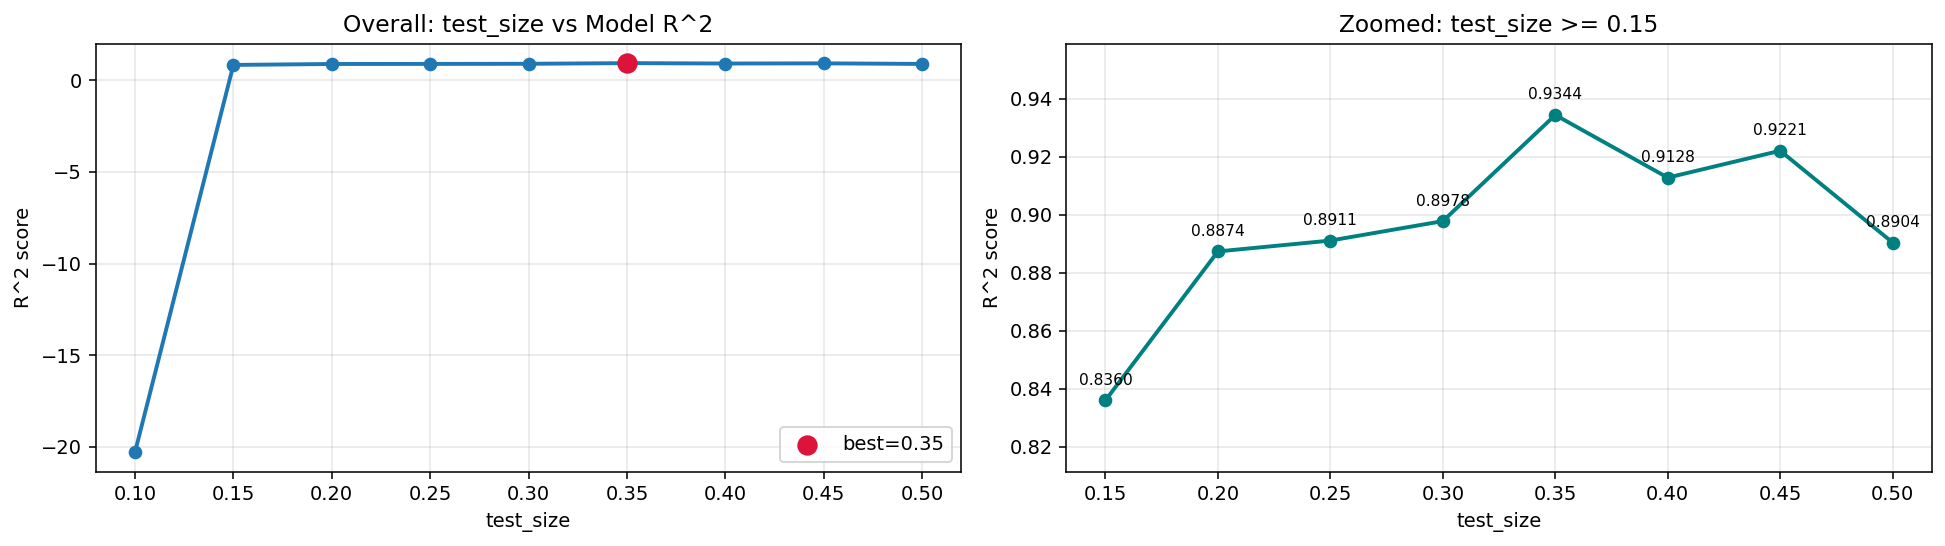

Selected best test_size: 0.35
Best R^2 score: 0.9344


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

test_sizes = np.arange(0.1, 0.55, 0.05)
scores = []

for ts in test_sizes:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y, test_size=ts, random_state=42
    )
    model_tmp = LinearRegression()
    model_tmp.fit(X_train_tmp, y_train_tmp)
    scores.append(model_tmp.score(X_test_tmp, y_test_tmp))

best_idx = int(np.argmax(scores))
best_test_size = float(test_sizes[best_idx])

score_arr = np.array(scores)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=140)

# Overall trend
axes[0].plot(test_sizes, score_arr, marker="o", linewidth=2)
axes[0].scatter(
    best_test_size, score_arr[best_idx], color="crimson", s=90, zorder=3,
    label=f"best={best_test_size:.2f}"
)
axes[0].set_title("Overall: test_size vs Model R^2")
axes[0].set_xlabel("test_size")
axes[0].set_ylabel("R^2 score")
axes[0].set_xticks(test_sizes)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Zoom in to highlight minute changes after 0.15
mask = test_sizes >= 0.15
zoom_x = test_sizes[mask]
zoom_y = score_arr[mask]
zoom_margin = max((zoom_y.max() - zoom_y.min()) * 0.25, 0.0005)

axes[1].plot(zoom_x, zoom_y, marker="o", linewidth=2, color="teal")
axes[1].set_title("Zoomed: test_size >= 0.15")
axes[1].set_xlabel("test_size")
axes[1].set_ylabel("R^2 score")
axes[1].set_xticks(zoom_x)
axes[1].set_ylim(zoom_y.min() - zoom_margin, zoom_y.max() + zoom_margin)
axes[1].grid(True, alpha=0.3)

for x_val, y_val in zip(zoom_x, zoom_y):
    axes[1].annotate(
        f"{y_val:.4f}",
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print(f"Selected best test_size: {best_test_size:.2f}")
print(f"Best R^2 score: {score_arr[best_idx]:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=best_test_size, random_state=42
)


In [7]:
X_train

,Mileage,Age(yrs)
18,87600,8
16,28000,2
13,58780,4
2,57000,5
9,67000,6
19,52000,5
4,46000,4
12,59000,5
7,72000,6
10,83000,7


In [8]:
X_test

,Mileage,Age(yrs)
0,69000,6
17,69000,5
15,25400,3
1,35000,3
8,91000,8
5,59000,5
11,79000,7
3,22500,2


In [9]:
y_train

18    12800
16    35500
13    27500
2     26100
9     22000
19    28200
4     31500
12    26000
7     19300
10    18700
14    19400
6     32000
Name: Sell Price($), dtype: int64

In [10]:
y_test

0     18000
17    19700
15    35000
1     34000
8     12000
5     26750
11    19500
3     40000
Name: Sell Price($), dtype: int64

In [11]:
from sklearn.linear_model import LinearRegression
lrm = LinearRegression()
lrm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
X_test

,Mileage,Age(yrs)
0,69000,6
17,69000,5
15,25400,3
1,35000,3
8,91000,8
5,59000,5
11,79000,7
3,22500,2


In [13]:
lrm.predict(X_test)

array([22356.78674753, 22670.08580024, 38086.27707756, 34829.85289292,
       14267.54988564, 26062.19432591, 18651.37916915, 39383.28760272])

In [14]:
y_test

0     18000
17    19700
15    35000
1     34000
8     12000
5     26750
11    19500
3     40000
Name: Sell Price($), dtype: int64

In [15]:
lrm.score(X_test, y_test)

0.9344430437041924